#  Game Theory Meet Explainable AI


In [ ]:
import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import lightgbm as lgb
import shap

class WineClusteringAnalysis:
    def __init__(self):
        """Initialize the wine clustering analysis."""
        self.data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
        self.df = None
        self.X = None
        self.y = None
        self.X_scaled = None
        self.pca_components = None
        self.kmeans_model = None
        self.cluster_predictions = None
        self.shap_values = None
        self.lgb_model = None
        self.all_features = None

    def load_data(self):
        """Load the wine dataset."""
        self.df = pd.read_csv(self.data_url, sep=';')
        print("Dataset shape:", self.df.shape)
        print("\nFirst few rows:")
        print(self.df.head())
        print("\nFeature statistics:")
        print(self.df.describe())

        self.X = self.df.drop(columns='quality')
        self.all_features = self.X.columns
        self.y = self.df['quality']
        return self

    def plot_initial_features(self):
        """Create initial feature visualization."""
        chart = alt.Chart(self.df).mark_point().encode(
            x='fixed acidity',
            y='volatile acidity',
            color='quality:N',
            tooltip=['quality']
        ).interactive()
        return chart

    def scale_features(self):
        """Scale the features using StandardScaler."""
        scaler = StandardScaler()
        self.X_scaled = scaler.fit_transform(self.X)
        return self

    def perform_pca_analysis(self):
        """Perform complete PCA analysis with visualizations."""
        # Full PCA
        pca = PCA().fit(self.X_scaled)
        df_plot = pd.DataFrame({
            'Component Number': 1 + np.arange(self.X.shape[1]),
            'Cumulative explained variance': np.cumsum(pca.explained_variance_ratio_)
        })

        variance_chart = alt.Chart(df_plot).mark_bar().encode(
            x=alt.X('Component Number:N', axis=alt.Axis(labelAngle=0)),
            y=alt.Y('Cumulative explained variance',
                   axis=alt.Axis(format='%')),
            tooltip=[alt.Tooltip('Cumulative explained variance', format='.0%')]
        ).properties(
            title='Cumulative explained variance',
            width=400
        )

        # 2D PCA for visualization
        twod_pca = PCA(n_components=2)
        X_pca = twod_pca.fit_transform(self.X_scaled)
        self.df['pca1'] = X_pca[:,0]
        self.df['pca2'] = X_pca[:,1]

        # Create loadings visualization
        df_loadings = pd.DataFrame(
            data=twod_pca.components_.T,
            columns=['pca1', 'pca2'],
            index=self.all_features
        ).reset_index()

        loadings_chart1 = alt.Chart(df_loadings).mark_bar().encode(
            y=alt.Y('index:O', title=None),
            x='pca1',
            color=alt.Color('pca1', scale=alt.Scale(scheme='viridis'))
        )

        loadings_chart2 = alt.Chart(df_loadings).mark_bar().encode(
            y=alt.Y('index:O', title=None),
            x='pca2',
            color=alt.Color('pca2', scale=alt.Scale(scheme='viridis'))
        )

        loadings_chart = (loadings_chart1 & loadings_chart2).properties(
            title='Loadings of the first two principal components'
        )

        return variance_chart, loadings_chart

    def perform_kmeans_analysis(self, max_clusters=10):
        """Perform KMeans analysis with different numbers of clusters."""
        km_scores = []
        km_silhouette = []
        km_db_score = []

        for i in range(2, max_clusters + 1):
            km = KMeans(n_clusters=i, random_state=1301).fit(self.X_scaled)
            preds = km.predict(self.X_scaled)

            score = km.score(self.X_scaled)
            silhouette = silhouette_score(self.X_scaled, preds)
            db = davies_bouldin_score(self.X_scaled, preds)

            print(f"Score for number of cluster(s) {i}: {score:.3f}")
            print(f"Silhouette score for number of cluster(s) {i}: {silhouette:.3f}")
            print(f"Davies Bouldin score for number of cluster(s) {i}: {db:.3f}")
            print('-' * 100)

            km_scores.append(-score)
            km_silhouette.append(silhouette)
            km_db_score.append(db)

        # Plot metrics
        df_metrics = pd.DataFrame({
            'Number of clusters': list(range(2, max_clusters + 1)),
            'kmean_score': km_scores,
            'silhouette_score': km_silhouette,
            'davies_bouldin_score': km_db_score
        })

        metrics_charts = []
        for metric in ['kmean_score', 'silhouette_score', 'davies_bouldin_score']:
            chart = alt.Chart(df_metrics).mark_line(point=True).encode(
                x=alt.X('Number of clusters:N', axis=alt.Axis(labelAngle=0)),
                y=alt.Y(metric),
                tooltip=[alt.Tooltip(metric, format='.2f')]
            ).properties(
                title=f'{metric} vs number of clusters',
                width=400
            )
            metrics_charts.append(chart)

        return alt.vconcat(*metrics_charts)

    def perform_clustering(self, n_clusters=3):
        """Perform final clustering with specified number of clusters."""
        self.kmeans_model = KMeans(n_clusters=n_clusters, random_state=1301)
        self.cluster_predictions = self.kmeans_model.fit_predict(self.X_scaled)
        self.df['cluster'] = self.cluster_predictions

        # Create cluster visualization
        selection = alt.selection_multi(fields=['cluster'], bind='legend')

        cluster_chart = alt.Chart(self.df).mark_circle(size=60).encode(
            x=alt.X('pca1', title='Principal component 1'),
            y=alt.Y('pca2', title='Principal component 2'),
            color=alt.Color('cluster:N', scale=alt.Scale(scheme='category10')),
            opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
            tooltip=['cluster'] + list(self.all_features)
        ).add_selection(selection)

        return cluster_chart

    def analyze_clusters_shap(self):
        """Analyze clusters using SHAP values."""
        # Train LightGBM classifier
        params = {
            'objective': 'multiclass',
            'is_unbalance': True,
            'random_state': 1301
        }
        self.lgb_model = lgb.LGBMClassifier(**params)
        self.lgb_model.fit(self.X, self.cluster_predictions)

        # Calculate SHAP values
        explainer = shap.TreeExplainer(self.lgb_model)
        self.shap_values = explainer.shap_values(self.X)

        # Plot SHAP summary plots for each cluster
        for cluster in range(len(np.unique(self.cluster_predictions))):
            plt.figure()
            shap.summary_plot(
                self.shap_values[cluster],
                self.X,
                show=False
            )
            plt.title(f'Cluster {cluster} SHAP Values')
            plt.tight_layout()
            plt.show()

    def analyze_cluster_quality(self):
        """Analyze wine quality distribution across clusters."""
        # Calculate quality statistics
        quality_stats = self.df.groupby('cluster')['quality'].describe()
        print("Quality statistics per cluster:")
        print(quality_stats)

        # Create quality distribution visualization
        quality_chart = alt.Chart(self.df).transform_density(
            density='quality',
            bandwidth=0.3,
            groupby=['cluster'],
            extent=[3, 9],
            counts=True,
            steps=200
        ).mark_area().encode(
            alt.X('value:Q'),
            alt.Y('density:Q', stack='zero'),
            alt.Color('cluster:N')
        ).properties(
            title='Distribution of quality of the wines per cluster',
            width=400,
            height=100
        )

        return quality_chart

    def analyze_clusters_shap_detailed(self):
        """Perform detailed SHAP analysis for clusters with multiple visualization types."""
        # Train LightGBM classifier if not already trained
        if self.lgb_model is None:
            params = {
                'objective': 'multiclass',
                'is_unbalance': True,
                'random_state': 1301
            }
            self.lgb_model = lgb.LGBMClassifier(**params)
            self.lgb_model.fit(self.X, self.cluster_predictions)

            # Calculate SHAP values if not already calculated
            explainer = shap.TreeExplainer(self.lgb_model)
            self.shap_values = explainer.shap_values(self.X)

        # 1. Global Feature Importance
        plt.figure(figsize=(12, 6))
        shap.summary_plot(self.shap_values, self.X, plot_type="bar", show=False)
        plt.title('Global Feature Importance Across All Clusters')
        plt.tight_layout()
        plt.show()

        # 2. Per-Cluster Analysis
        for cluster in range(len(np.unique(self.cluster_predictions))):
            print(f"\n{'='*20} Analysis for Cluster {cluster} {'='*20}")
            cluster_mask = self.cluster_predictions == cluster


            # 2.3 Numerical Analysis
            # Mean SHAP values
            mean_shap = np.abs(self.shap_values[cluster]).mean(axis=0)
            feature_importance = pd.DataFrame({
                'Feature': self.X.columns,
                'SHAP Importance': mean_shap
            }).sort_values('SHAP Importance', ascending=False)

            # Cluster characteristics
            cluster_means = self.X[cluster_mask].mean()
            overall_means = self.X.mean()
            std_devs = self.X.std()

            characteristics = pd.DataFrame({
                'Feature': self.X.columns,
                'Cluster_Mean': cluster_means,
                'Overall_Mean': overall_means,
                'Std_Difference': (cluster_means - overall_means) / std_devs
            }).sort_values('Std_Difference', key=abs, ascending=False)

            print("\nTop 5 Most Important Features:")
            print(feature_importance.head().to_string(index=False))
            print("\nMost Distinctive Characteristics (in standard deviations):")
            print(characteristics.head().to_string(index=False))


        # 3. Quality Analysis per Cluster
        plt.figure(figsize=(10, 6))
        for cluster in range(len(np.unique(self.cluster_predictions))):
            cluster_mask = self.cluster_predictions == cluster
            cluster_quality = self.df[cluster_mask]['quality']

            plt.hist(cluster_quality, alpha=0.5, label=f'Cluster {cluster}',
                    bins=np.arange(min(self.df['quality'])-0.5, max(self.df['quality'])+1.5, 1))

        plt.title('Quality Distribution by Cluster')
        plt.xlabel('Quality Score')
        plt.ylabel('Count')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def analyze_clusters_force_plots(self):
        """
        Generate force plots for representative samples of each cluster,
        showing how features contribute to cluster membership decisions.
        """
        if self.lgb_model is None:
            # Train the model if not already trained
            params = {
                'objective': 'multiclass',
                'is_unbalance': True,
                'random_state': 1301
            }
            self.lgb_model = lgb.LGBMClassifier(**params)
            self.lgb_model.fit(self.X, self.cluster_predictions)

            # Calculate SHAP values if not already calculated
            explainer = shap.TreeExplainer(self.lgb_model)
            self.shap_values = explainer.shap_values(self.X)

        # For each cluster
        for cluster in range(len(np.unique(self.cluster_predictions))):
            print(f"\n{'='*20} Force Plot Analysis for Cluster {cluster} {'='*20}")

            # Get samples belonging to this cluster
            cluster_mask = self.cluster_predictions == cluster
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) > 0:
                # Calculate average SHAP magnitude for each sample in cluster
                cluster_shap_magnitudes = np.abs(self.shap_values[cluster][cluster_mask]).mean(axis=1)

                # Find the representative sample (median SHAP magnitude)
                median_idx = cluster_indices[np.argsort(cluster_shap_magnitudes)[len(cluster_indices)//2]]

                # Print feature values for this representative sample
                representative_sample = self.X.iloc[median_idx]
                print("\nRepresentative Sample Feature Values:")
                for feature, value in representative_sample.items():
                    print(f"{feature}: {value:.3f}")

                # Create force plot
                plt.figure(figsize=(20, 3))
                shap.force_plot(
                    base_value=self.lgb_model.predict_proba(self.X)[median_idx][cluster],
                    shap_values=self.shap_values[cluster][median_idx],
                    features=self.X.iloc[median_idx],
                    feature_names=list(self.X.columns),
                    matplotlib=True,
                    show=False
                )
                plt.title(f'Cluster {cluster} - Representative Sample Force Plot')
                plt.tight_layout()
                plt.show()

                # Print cluster summary statistics
                print("\nCluster Summary Statistics:")
                cluster_stats = self.X[cluster_mask].describe()
                print(cluster_stats.round(3))

In [ ]:
# Run the complete analysis
analyzer = WineClusteringAnalysis()
analyzer.load_data()



Dataset shape: (4898, 12)

First few rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8        6  

In [ ]:
# Create initial feature visualization
initial_viz = analyzer.plot_initial_features()
display(initial_viz)

alt.Chart(...)

In [ ]:
# Scale features and perform PCA analysis
analyzer.scale_features()
variance_chart, loadings_chart = analyzer.perform_pca_analysis()
display(variance_chart)
display(loadings_chart)

alt.Chart(...)

alt.VConcatChart(...)

In [ ]:
# Perform KMeans analysis
kmeans_metrics = analyzer.perform_kmeans_analysis()
display(kmeans_metrics)

Score for number of cluster(s) 2: -42548.697
Silhouette score for number of cluster(s) 2: 0.214
Davies Bouldin score for number of cluster(s) 2: 1.775
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 3: -39063.244
Silhouette score for number of cluster(s) 3: 0.145
Davies Bouldin score for number of cluster(s) 3: 2.102
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 4: -35986.966
Silhouette score for number of cluster(s) 4: 0.159
Davies Bouldin score for number of cluster(s) 4: 1.809
----------------------------------------------------------------------------------------------------
Score for number of cluster(s) 5: -33699.044
Silhouette score for number of cluster(s) 5: 0.144
Davies Bouldin score for number of cluster(s) 5: 1.768
---------------------------------------------------------------------------------------------

alt.VConcatChart(...)

In [ ]:
# Perform final clustering and visualize
cluster_viz = analyzer.perform_clustering()
display(cluster_viz)



alt.Chart(...)

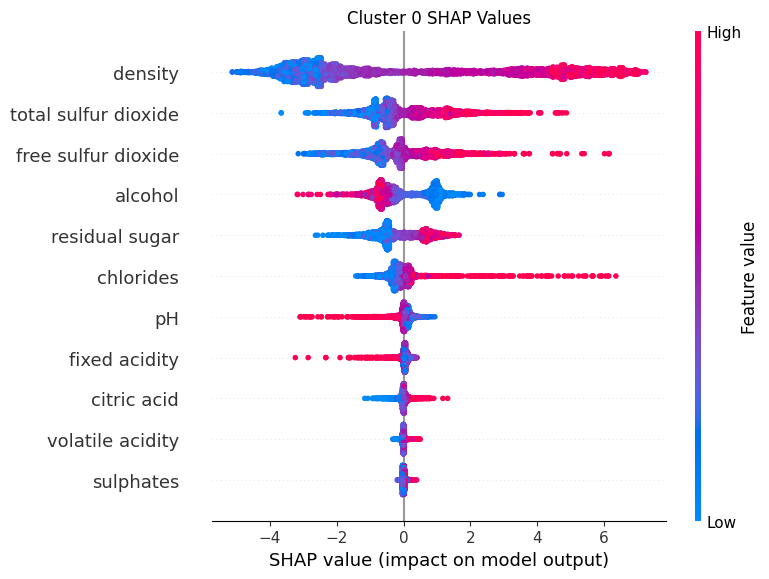

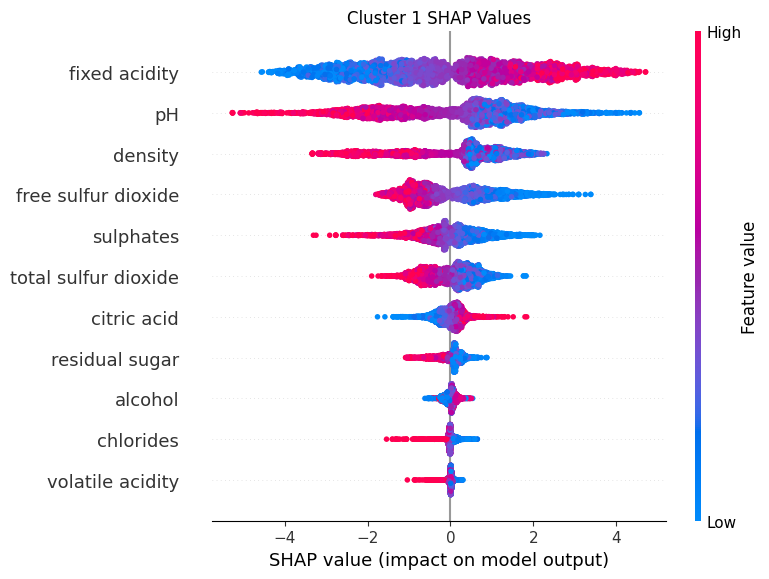

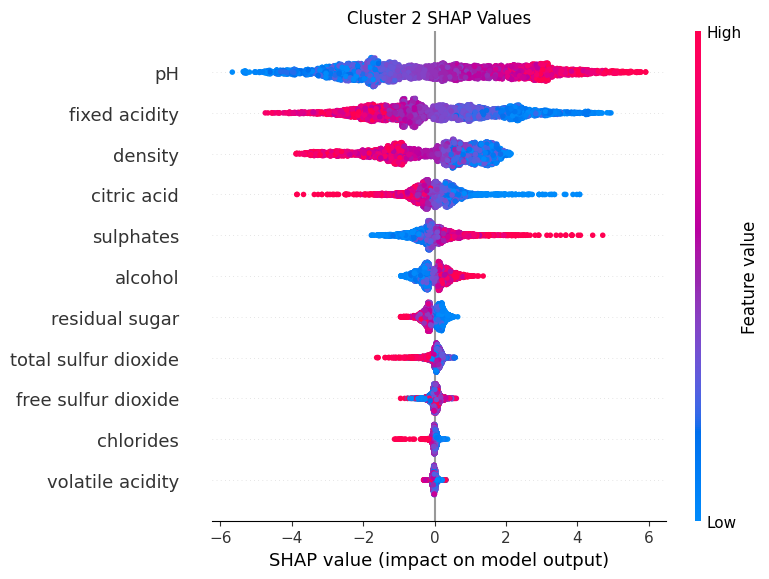

In [ ]:
# Analyze clusters using SHAP values
analyzer.analyze_clusters_shap()

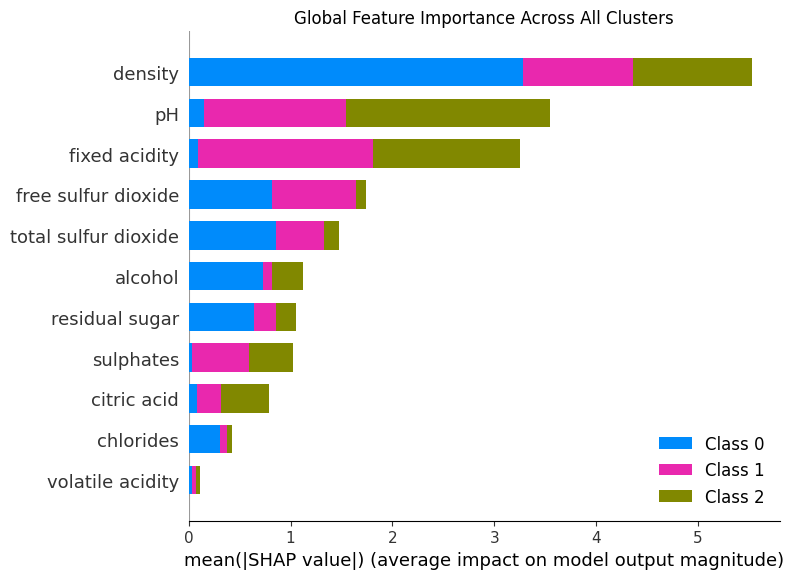


==================== Analysis for Cluster 0 ====================

Top 5 Most Important Features:
              Feature  SHAP Importance
              density         3.280948
 total sulfur dioxide         0.853102
  free sulfur dioxide         0.821600
              alcohol         0.726578
       residual sugar         0.641778

Most Distinctive Characteristics (in standard deviations):
              Feature  Cluster_Mean  Overall_Mean  Std_Difference
              density      0.997027      0.994027        1.002880
       residual sugar     11.122376      6.391415        0.932750
              alcohol      9.487229     10.514267       -0.834569
 total sulfur dioxide    172.183787    138.360657        0.795875
  free sulfur dioxide     46.264575     35.308085        0.644229

==================== Analysis for Cluster 1 ====================

Top 5 Most Important Features:
             Feature  SHAP Importance
       fixed acidity         1.714355
                  pH         1.399850


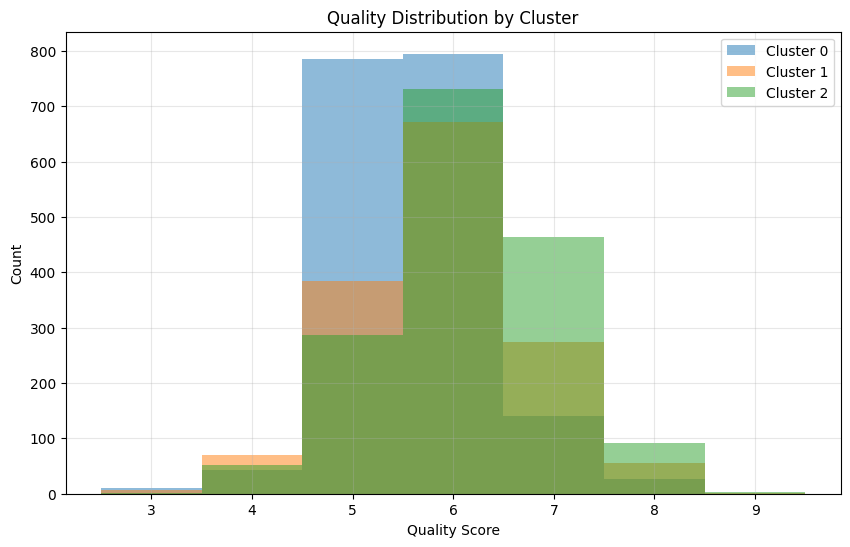

In [ ]:
analyzer.analyze_clusters_shap_detailed()



==================== Force Plot Analysis for Cluster 0 ====================

Representative Sample Feature Values:
fixed acidity: 7.900
volatile acidity: 0.170
citric acid: 0.320
residual sugar: 1.600
chlorides: 0.053
free sulfur dioxide: 47.000
total sulfur dioxide: 150.000
density: 0.995
pH: 3.290
sulphates: 0.760
alcohol: 9.600


<Figure size 2000x300 with 0 Axes>

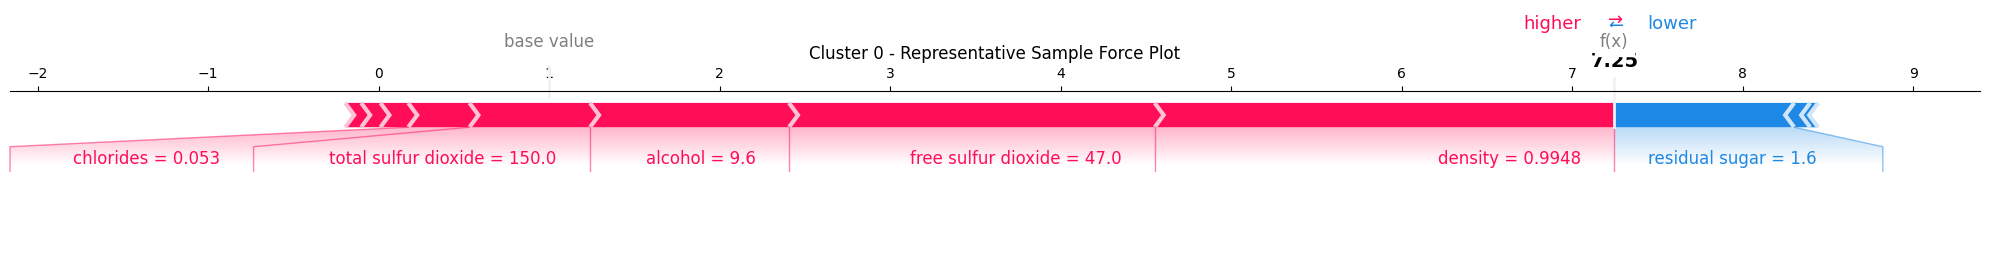


Cluster Summary Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1801.000          1801.000     1801.000        1801.000   
mean           6.960             0.282        0.363          11.122   
std            0.682             0.094        0.137           4.490   
min            4.200             0.105        0.040           0.800   
25%            6.500             0.220        0.270           8.000   
50%            6.900             0.270        0.330          11.300   
75%            7.400             0.320        0.430          14.200   
max           10.700             0.965        1.000          65.800   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1801.000             1801.000              1801.000  1801.000   
mean       0.055               46.265               172.184     0.997   
std        0.029               17.018                35.693     0.002   
min        0.024                6.000  

<Figure size 2000x300 with 0 Axes>

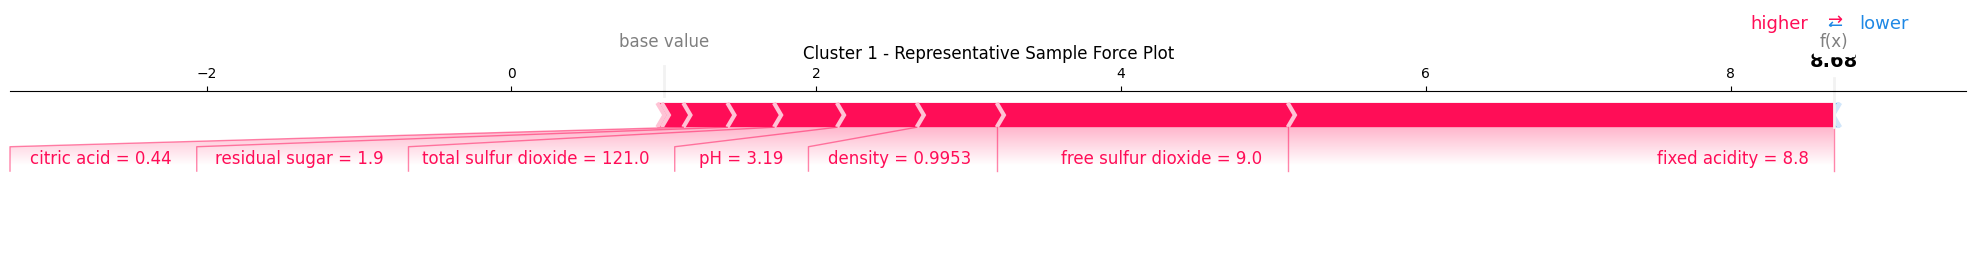


Cluster Summary Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1466.000          1466.000     1466.000        1466.000   
mean           7.427             0.274        0.349           3.929   
std            0.796             0.096        0.110           3.113   
min            5.700             0.090        0.060           0.600   
25%            6.900             0.200        0.280           1.400   
50%            7.300             0.260        0.330           2.500   
75%            7.900             0.320        0.400           6.000   
max           14.200             1.005        1.660          19.800   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1466.000             1466.000              1466.000  1466.000   
mean       0.041               25.964               114.908     0.993   
std        0.017               12.222                32.226     0.002   
min        0.014                2.000  

<Figure size 2000x300 with 0 Axes>

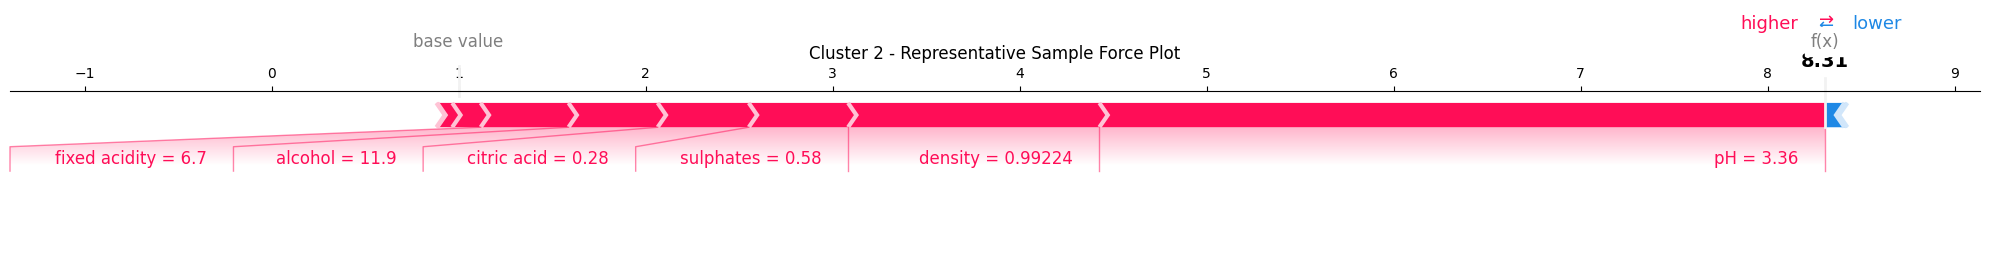


Cluster Summary Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1631.000          1631.000     1631.000        1631.000   
mean           6.224             0.277        0.289           3.381   
std            0.593             0.111        0.096           2.657   
min            3.800             0.080        0.000           0.700   
25%            5.800             0.200        0.250           1.400   
50%            6.200             0.260        0.290           2.200   
75%            6.600             0.330        0.340           4.900   
max            8.000             1.100        0.740          15.500   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1631.000             1631.000              1631.000  1631.000   
mean       0.040               31.609               122.092     0.992   
std        0.011               13.786                32.592     0.002   
min        0.009                3.000  

In [ ]:
analyzer.analyze_clusters_force_plots()
